In [213]:
import pandas as pd

In [214]:
base = '/Users/ryan/Downloads/FF-Python-Analytics-master/'
routes = pd.read_csv(base + 'route_coords.csv')
carries = pd.read_csv(base + 'carry_coords.csv')
passes = pd.read_csv(base + 'pass_locations.csv')     # one row per pass: pass_type, x_coord, y_coord
routes = routes[routes['season'] == 2025]
carries = carries[carries['season'] == 2025]
passes = passes[passes['season'] == 2025]
df = routes   # (kept so old cells that used `df` still work)

In [215]:
display(routes.head(3))
display(carries.head(3))

,game_id,season,season_type,week,team,esb_id,name,position,route_id,route_type,touchdown,start_ok,point,segment,x_coord,y_coord
0,2025090700,2025,REG,1,ATL,LON013463,Drake London,WR,1,COMPLETE,False,True,0,route,2.76,-1.23
1,2025090700,2025,REG,1,ATL,LON013463,Drake London,WR,1,COMPLETE,False,True,1,route,2.29,-1.34
2,2025090700,2025,REG,1,ATL,LON013463,Drake London,WR,1,COMPLETE,False,True,2,route,1.84,-1.54


,game_id,season,season_type,week,team,esb_id,name,position,carry_id,gain_class,touchdown,fumble_lost,handoff_ok,point,x_coord,y_coord
0,2025090700,2025,REG,1,ATL,ROB368260,Bijan Robinson,RB,1,SHORT,False,False,True,0,-5.40,-3.08
1,2025090700,2025,REG,1,ATL,ROB368260,Bijan Robinson,RB,1,SHORT,False,False,True,1,-5.87,-2.93
2,2025090700,2025,REG,1,ATL,ROB368260,Bijan Robinson,RB,1,SHORT,False,False,True,2,-6.34,-2.78


In [216]:
bijan = routes[(routes['name'] == 'Bijan Robinson') & (routes['week'] == 1)]                  # his route-chart targets
bijan_carries = carries[(carries['name'] == 'Bijan Robinson') & (carries['week'] == 1)]       # his rushes

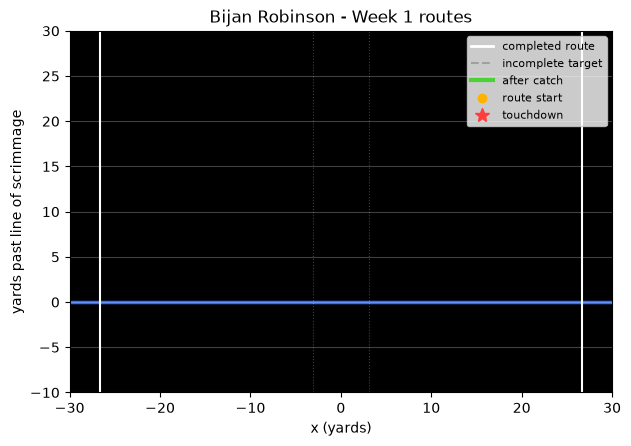

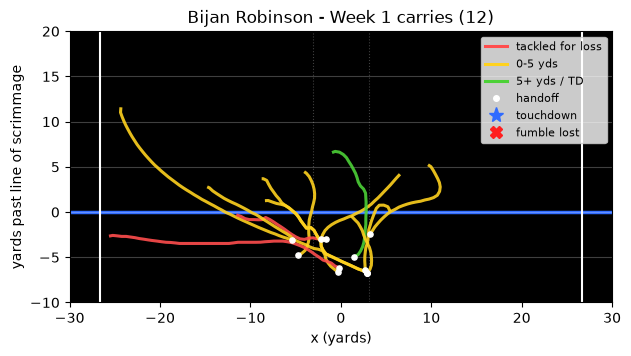

In [217]:
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def draw_field(ax, ymin=-10, ymax=40):
    """Simple top-down field: sidelines, LOS, 5-yd lines, hash marks. x in yards, y = yards past LOS."""
    ymin, ymax = int(math.floor(ymin)), int(math.ceil(ymax))          # range() needs ints
    ax.set_facecolor('black')                                        # black field, so heatmap colors (inferno etc.) read cleanly
    for y in range(ymin - ymin % 5, ymax + 1, 5):
        ax.axhline(y, color='white', alpha=0.25, lw=0.8)
    ax.axhline(0, color='#2f6bff', lw=2.5, zorder=1)                 # line of scrimmage
    for x in (-26.67, 26.67):
        ax.axvline(x, color='white', lw=1.5)                          # sidelines
    for x in (-3.08, 3.08):
        ax.axvline(x, color='white', alpha=0.25, lw=0.8, ls=':')     # hashes
    ax.set_xlim(-30, 30)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal')
    ax.set_xlabel('x (yards)')
    ax.set_ylabel('yards past line of scrimmage')


def count(data, id_col):
    """Number of routes/carries in `data`. The ids restart at 1 every game, so count (game_id, id) pairs."""
    return data.groupby(['game_id', id_col]).ngroups


# ---------------------------------------------------------------- routes
ROUTE_STYLE = {'COMPLETE': dict(color='white', lw=2, alpha=0.9),
               'INCOMPLETE': dict(color='#9aa0a6', lw=1.5, alpha=0.8, ls='--')}

def plot_routes(data, title, ax=None):
    ax = ax or plt.subplots(figsize=(7, 8))[1]
    draw_field(ax, ymax=max(30, data['y_coord'].max() + 3))
    for _, r in data.groupby(['game_id', 'route_id']):              # one line per route per game
        r = r.sort_values('point')
        ax.plot(r['x_coord'], r['y_coord'], **ROUTE_STYLE[r['route_type'].iloc[0]], zorder=3)
        ac = r[r['segment'] == 'after_catch']                        # yards after catch in green
        if len(ac):
            ax.plot(ac['x_coord'], ac['y_coord'], color='#4cd137', lw=3, zorder=4)
        ax.scatter(r['x_coord'].iloc[0], r['y_coord'].iloc[0], s=18, color='#ffb300', zorder=5)   # start
        if r['touchdown'].iloc[0]:
            ax.scatter(r['x_coord'].iloc[-1], r['y_coord'].iloc[-1], s=120, marker='*', color='#ff3d3d', zorder=6)
    ax.set_title(title)
    return ax

route_legend = [Line2D([], [], color='white', lw=2, label='completed route'),
                Line2D([], [], color='#9aa0a6', lw=1.5, ls='--', label='incomplete target'),
                Line2D([], [], color='#4cd137', lw=3, label='after catch'),
                Line2D([], [], color='#ffb300', marker='o', ls='', label='route start'),
                Line2D([], [], color='#ff3d3d', marker='*', ls='', ms=10, label='touchdown')]


# ---------------------------------------------------------------- carries
CARRY_COLORS = {'LOSS': '#ff4d4d', 'SHORT': '#ffd21f', 'LONG': '#4cd137'}   # same colours as the NGS chart

def plot_carries(data, title, ax=None):
    ax = ax or plt.subplots(figsize=(7, 6))[1]
    draw_field(ax, ymin=-10, ymax=max(20, data['y_coord'].max() + 3))
    for _, r in data.groupby(['game_id', 'carry_id']):              # one line per carry per game
        r = r.sort_values('point')
        ax.plot(r['x_coord'], r['y_coord'], color=CARRY_COLORS[r['gain_class'].iloc[0]], lw=2.2, alpha=0.9, zorder=3)
        ax.scatter(r['x_coord'].iloc[0], r['y_coord'].iloc[0], s=14, color='white', zorder=5)      # handoff
        if r['touchdown'].iloc[0]:
            ax.scatter(r['x_coord'].iloc[-1], r['y_coord'].iloc[-1], s=140, marker='*', color='#2f6bff',
                       edgecolor='white', zorder=6)
        if r['fumble_lost'].iloc[0]:
            ax.scatter(r['x_coord'].iloc[-1], r['y_coord'].iloc[-1], s=90, marker='X', color='#ff1f1f',
                       edgecolor='white', zorder=6)
    ax.set_title(title)
    return ax

carry_legend = [Line2D([], [], color=CARRY_COLORS['LOSS'], lw=2.2, label='tackled for loss'),
                Line2D([], [], color=CARRY_COLORS['SHORT'], lw=2.2, label='0-5 yds'),
                Line2D([], [], color=CARRY_COLORS['LONG'], lw=2.2, label='5+ yds / TD'),
                Line2D([], [], color='white', marker='o', ls='', ms=4, label='handoff'),
                Line2D([], [], color='#2f6bff', marker='*', ls='', ms=11, label='touchdown'),
                Line2D([], [], color='#ff1f1f', marker='X', ls='', ms=8, label='fumble lost')]


# --- Bijan Robinson, week 1: every route target ---
ax = plot_routes(bijan, 'Bijan Robinson - Week 1 routes')
ax.legend(handles=route_legend, loc='upper right', fontsize=8)
plt.show()

# --- Bijan Robinson, week 1: every carry ---
ax = plot_carries(bijan_carries, f'Bijan Robinson - Week 1 carries ({count(bijan_carries, "carry_id")})')
ax.legend(handles=carry_legend, loc='upper right', fontsize=8)
plt.show()


In [218]:
print('route players, week 2:', routes[routes['week'] == 2]['name'].unique())
print('carry players, week 2:', carries[carries['week'] == 2]['name'].unique())

route players, week 2: <ArrowStringArray>
[      'Drake London',       'Trey McBride',        'Zay Flowers',
       'Keon Coleman',  'Tetairoa McMillan',     'Hunter Renfrow',
        'Rome Odunze',      'Ja'Marr Chase',        'Jerry Jeudy',
        'CeeDee Lamb',     'George Pickens',      'Troy Franklin',
  'Amon-Ra St. Brown',   'Jameson Williams',       'Tucker Kraft',
       'Nico Collins',       'Tyler Warren',        'Dyami Brown',
       'Travis Kelce',    'Tyquan Thornton',       'Keenan Allen',
      'Davante Adams',      'Jakobi Meyers',        'Tyreek Hill',
   'Justin Jefferson',       'Stefon Diggs',     'Rashid Shaheed',
       'Malik Nabers',  'Wan'Dale Robinson',     'Garrett Wilson',
      'DeVonta Smith',         'DK Metcalf', 'Jaxon Smith-Njigba',
     'Jauan Jennings',         'Mike Evans',      'Elic Ayomanor',
          'Zach Ertz']
Length: 37, dtype: str
carry players, week 2: <ArrowStringArray>
[     'Bijan Robinson',        'James Conner',       'Derrick Henr

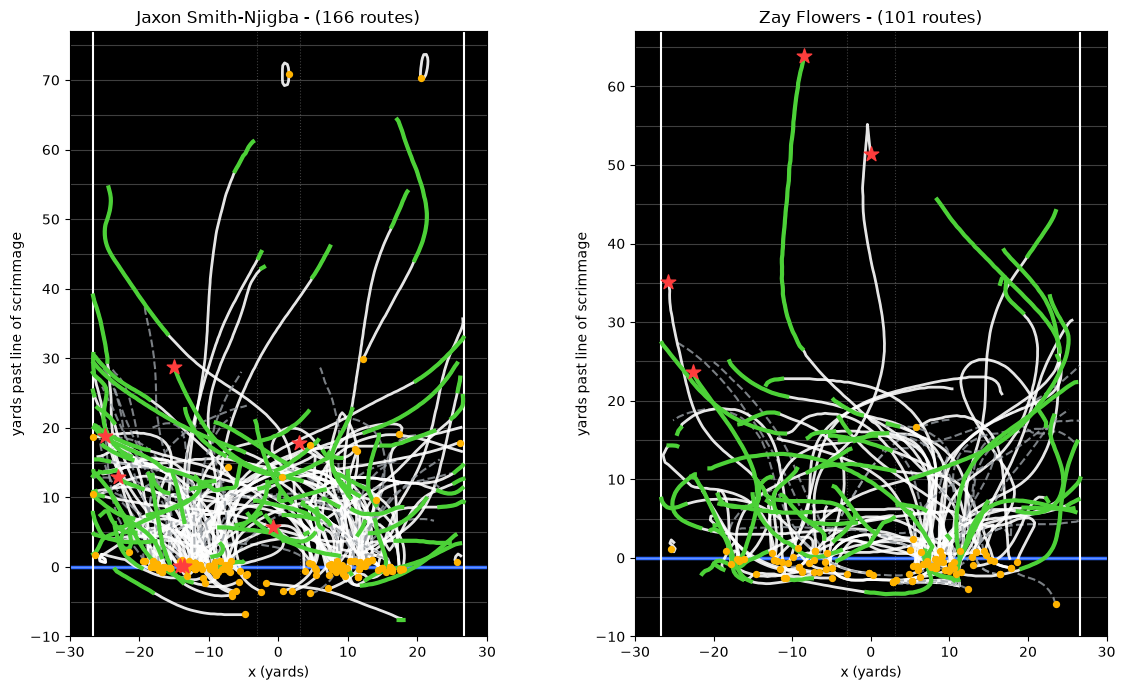

In [219]:
# --- ROUTES: compare several players side by side (change the names / weeks) ---
players = ['Jaxon Smith-Njigba', 'Zay Flowers']
weeks = list(range(1, 23))

fig, axes = plt.subplots(1, len(players), figsize=(6 * len(players), 7), squeeze=False)
axes = axes[0]
for ax, name in zip(axes, players):
    d = routes[(routes['name'] == name) & (routes['week'].isin(weeks))]
    if d.empty:
        ax.set_title(f'{name}: no data for weeks {weeks}')
        ax.axis('off')
        continue
    plot_routes(d, f'{name} - ({count(d, "route_id")} routes)', ax=ax)
plt.tight_layout()
plt.show()

In [220]:
carries[carries['name'] == 'Christian McCaffrey']

,game_id,season,season_type,week,team,esb_id,name,position,carry_id,gain_class,touchdown,fumble_lost,handoff_ok,point,x_coord,y_coord
245919,2025090709,2025,REG,1,SF,MCC035988,Christian McCaffrey,RB,1,SHORT,False,False,True,0,-5.71,-1.57
245920,2025090709,2025,REG,1,SF,MCC035988,Christian McCaffrey,RB,1,SHORT,False,False,True,1,-5.35,-1.28
245921,2025090709,2025,REG,1,SF,MCC035988,Christian McCaffrey,RB,1,SHORT,False,False,True,2,-5.01,-0.91
245922,2025090709,2025,REG,1,SF,MCC035988,Christian McCaffrey,RB,1,SHORT,False,False,True,3,-4.68,-0.53
245923,2025090709,2025,REG,1,SF,MCC035988,Christian McCaffrey,RB,1,SHORT,False,False,True,4,-4.35,-0.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255123,2026011701,2025,POST,20,SF,MCC035988,Christian McCaffrey,RB,11,SHORT,False,False,True,7,3.57,-2.77
255124,2026011701,2025,POST,20,SF,MCC035988,Christian McCaffrey,RB,11,SHORT,False,False,True,8,3.56,-2.27
255125,2026011701,2025,POST,20,SF,MCC035988,Christian McCaffrey,RB,11,SHORT,False,False,True,9,3.67,-1.78
255126,2026011701,2025,POST,20,SF,MCC035988,Christian McCaffrey,RB,11,SHORT,False,False,True,10,3.77,-1.29


In [221]:
carries['name'].unique()

<ArrowStringArray>
[        'Bijan Robinson',         'Tyler Allgeier',           'James Conner',
             'Bam Knight',         'Michael Carter',        'Emari Demercado',
            'Trey Benson',          'Derrick Henry',             'James Cook',
              'Ray Davis',          'Chuba Hubbard',            'Rico Dowdle',
          'D'Andre Swift',          'Kyle Monangai',            'Chase Brown',
          'Samaje Perine',          'Dylan Sampson',       'Quinshon Judkins',
         'Raheim Sanders',       'Javonte Williams',            'Malik Davis',
            'Jaydon Blue',           'J.K. Dobbins',      'Jaleel McLaughlin',
              'RJ Harvey',       'David Montgomery',           'Jahmyr Gibbs',
            'Josh Jacobs',         'Emanuel Wilson',           'Chris Brooks',
             'Nick Chubb',            'Woody Marks',          'Jawhar Jordan',
         'British Brooks',        'Jonathan Taylor',             'DJ Giddens',
         'Travis Etienne',       

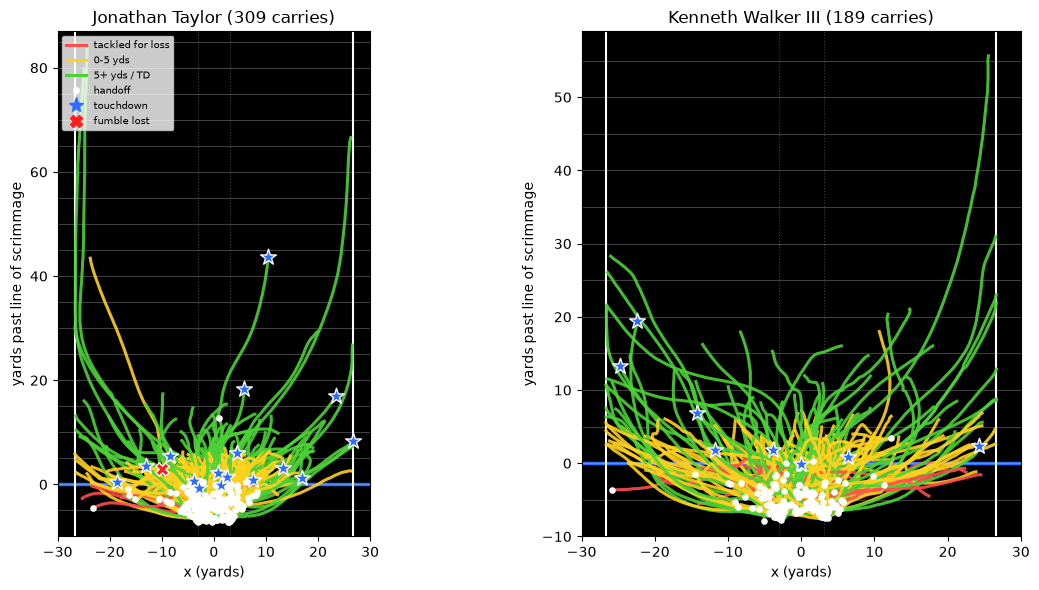

In [222]:
# --- CARRIES: compare several players side by side (change the names / week) ---
# tip: carries[carries['week'] == week]['name'].unique() lists who has data for that week
players = ['Jonathan Taylor', "Kenneth Walker III"]
weeks = list(range(1, 23))

fig, axes = plt.subplots(1, len(players), figsize=(6 * len(players), 6), squeeze=False)
axes = axes[0]
for ax, name in zip(axes, players):
    d = carries[(carries['name'] == name) & (carries['week'].isin(weeks))]
    if d.empty:
        ax.set_title(f'{name}: no data for weeks {weeks}')
        ax.axis('off')
        continue
    plot_carries(d, f'{name} ({count(d, "carry_id")} carries)', ax=ax)
axes[0].legend(handles=carry_legend, loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

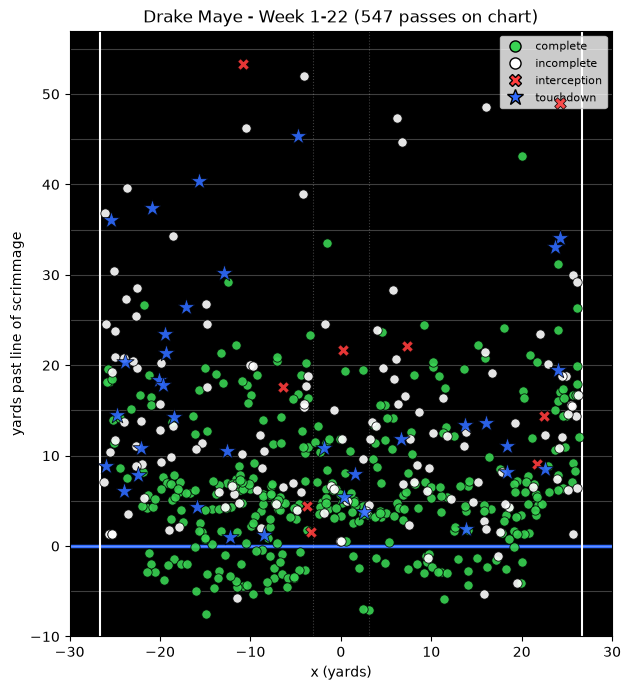

{'COMPLETE': 362, 'INCOMPLETE': 140, 'TOUCHDOWN': 35, 'INTERCEPTION': 10}


In [ ]:
# ---------------------------------------------------------------- passes
# Colours follow the NGS pass chart. NOTE: the chart doesn't draw every incompletion (throwaways, spikes...),
# so a QB can have fewer INCOMPLETE dots than (attempts - completions - interceptions).
PASS_STYLE = {'COMPLETE':     dict(color='#39d353', marker='o', s=45, label='complete'),
              'INCOMPLETE':   dict(color='white',   marker='o', s=45, label='incomplete'),
              'INTERCEPTION': dict(color='#ff3d3d', marker='X', s=70, label='interception'),
              'TOUCHDOWN':    dict(color='#2f6bff', marker='*', s=170, label='touchdown')}

def plot_passes(data, title, ax=None):
    ax = ax or plt.subplots(figsize=(7, 8))[1]
    draw_field(ax, ymin=-10, ymax=max(35, data['y_coord'].max() + 3))
    for ptype, style in PASS_STYLE.items():                            # draw TD / INT last so they sit on top
        d = data[data['pass_type'] == ptype]
        ax.scatter(d['x_coord'], d['y_coord'], edgecolor='black', linewidth=0.6, alpha=0.9,
                   zorder=4 if ptype in ('COMPLETE', 'INCOMPLETE') else 6,
                   **{k: v for k, v in style.items() if k != 'label'})
    ax.set_title(title)
    return ax

pass_legend = [Line2D([], [], color=s['color'], marker=s['marker'], ls='', ms=8 if k != 'TOUCHDOWN' else 12,
                      markeredgecolor='black', label=s['label']) for k, s in PASS_STYLE.items()]


# --- one QB, one week: every pass on the field ---
qb = 'Drake Maye'
weeks = list(range(1, 23))
d = passes[(passes['name'] == qb) & (passes['week'].isin(weeks))]
ax = plot_passes(d, f'{qb} - Week {weeks[0]}-{weeks[-1]} ({len(d)} passes on chart)')
ax.legend(handles=pass_legend, loc='upper right', fontsize=8)
plt.show()
print(d['pass_type'].value_counts().to_dict())

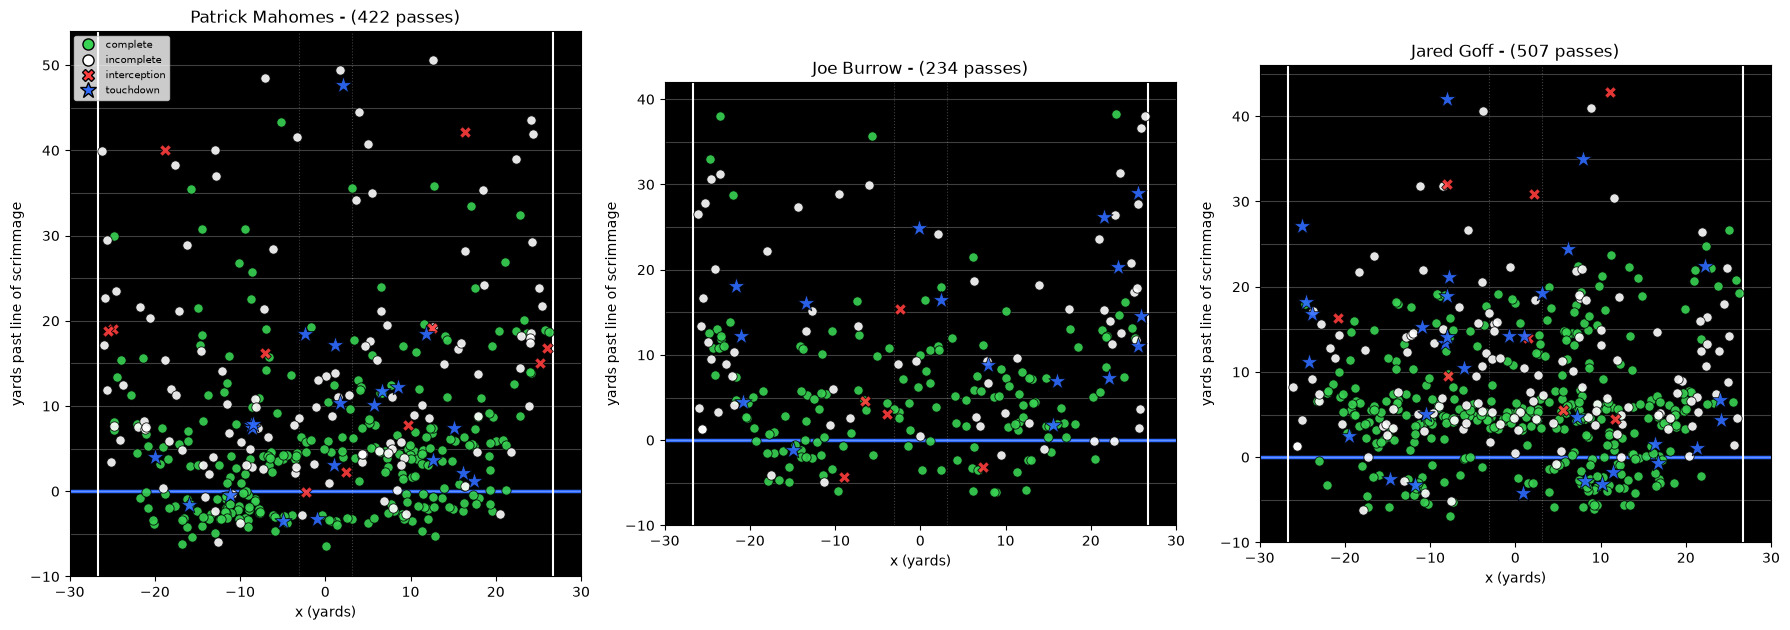

,passes,completions,avg_depth,avg_depth_completed
name,,,,
Jared Goff,507,368,7.4,6.2
Joe Burrow,234,166,8.0,6.3
Patrick Mahomes,422,291,8.4,5.7


In [224]:
# --- PASSES: compare several QBs side by side (change the names / weeks) ---
# tip: passes['name'].unique() lists the QBs that have data
qbs = ['Patrick Mahomes', 'Joe Burrow', 'Jared Goff']
weeks = list(range(1, 23))

fig, axes = plt.subplots(1, len(qbs), figsize=(6 * len(qbs), 7), squeeze=False)
axes = axes[0]
for ax, name in zip(axes, qbs):
    d = passes[(passes['name'] == name) & (passes['week'].isin(weeks))]
    if d.empty:
        ax.set_title(f'{name}: no data for weeks {weeks}')
        ax.axis('off')
        continue
    plot_passes(d, f'{name} - ({len(d)} passes)', ax=ax)
axes[0].legend(handles=pass_legend, loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

# quick per-QB summary of what's on the chart (depth = yards past the line of scrimmage)
summary = (passes[passes['week'].isin(weeks) & passes['name'].isin(qbs)]
           .assign(complete=lambda x: x['pass_type'].isin(['COMPLETE', 'TOUCHDOWN']))
           .groupby('name')
           .agg(passes=('pass_type', 'size'), completions=('complete', 'sum'),
                avg_depth=('y_coord', 'mean'), avg_depth_completed=('y_coord', lambda s: s[passes.loc[s.index, 'pass_type'].isin(['COMPLETE', 'TOUCHDOWN'])].mean()))
           .round(1))
summary

In [225]:
# ---------------------------------------------------------------- heatmaps
# Smoothed 2-D density of where points land on the field, instead of individual dots/lines.
# Same field, same yard coordinates as everything above.
import numpy as np
from scipy.ndimage import gaussian_filter

def field_heatmap(ax, x, y, ymin=-10, ymax=40, bin_yd=0.5, smooth_yd=2.2, cmap='inferno',
                  vmax=None, density=True, show_points=False):
    """
    Draw a smoothed density heatmap of (x, y) points (yards) on the field.
    density=True shows each cell's SHARE of this sample (so players/QBs with different sample
    sizes are visually comparable); pass the same `vmax` to several calls to share one color scale.
    show_points=True dots the raw points on top, useful for small samples.
    """
    draw_field(ax, ymin=ymin, ymax=ymax)
    x = np.asarray(x, float); y = np.asarray(y, float)
    ok = ~(np.isnan(x) | np.isnan(y))
    x, y = x[ok], y[ok]
    xedges = np.arange(-26.67, 26.67 + bin_yd, bin_yd)
    yedges = np.arange(ymin, ymax + bin_yd, bin_yd)
    hist, _, _ = np.histogram2d(x, y, bins=[xedges, yedges])
    hist = gaussian_filter(hist, sigma=smooth_yd / bin_yd)
    if density and hist.sum() > 0:
        hist = hist / len(x)                                # -> share of this player's points per cell
    hist_img = hist.T                                        # histogram2d is (x, y); imshow wants (row=y, col=x)
    masked = np.ma.masked_where(hist_img < hist_img.max() * 0.015, hist_img)   # near-zero -> transparent
    cm = plt.get_cmap(cmap).copy(); cm.set_bad(alpha=0)
    im = ax.imshow(masked, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower',
                   cmap=cm, alpha=0.88, zorder=2, vmax=vmax, aspect='auto', interpolation='bilinear')
    ax.axhline(0, color='#2f6bff', lw=2, zorder=6)                            # redraw field lines on
    for xx in (-26.67, 26.67):                                                # top so the heatmap
        ax.axvline(xx, color='white', lw=1.5, zorder=6)                       # never hides them
    for xx in (-3.08, 3.08):
        ax.axvline(xx, color='white', alpha=0.4, lw=0.8, ls=':', zorder=6)
    if show_points:
        ax.scatter(x, y, s=4, color='white', alpha=0.35, zorder=5, linewidths=0)
    return im, float(hist_img.max())


def catch_points(route_data):
    """
    Where each completed route was caught: the last point still labelled 'route' (i.e. just before
    'after_catch' starts, or the final point if there was no YAC). One row per completed route.
    """
    d = route_data[route_data['route_type'] == 'COMPLETE']
    pre = d[d['segment'] == 'route']
    idx = pre.groupby(['game_id', 'esb_id', 'route_id'])['point'].idxmax()
    return d.loc[idx, ['x_coord', 'y_coord']]


def handoff_points(carry_data):
    """Where each carry started (point 0), for carries whose start was traced cleanly (handoff_ok)."""
    d = carry_data[carry_data['handoff_ok'] & (carry_data['point'] == 0)]
    return d[['x_coord', 'y_coord']]

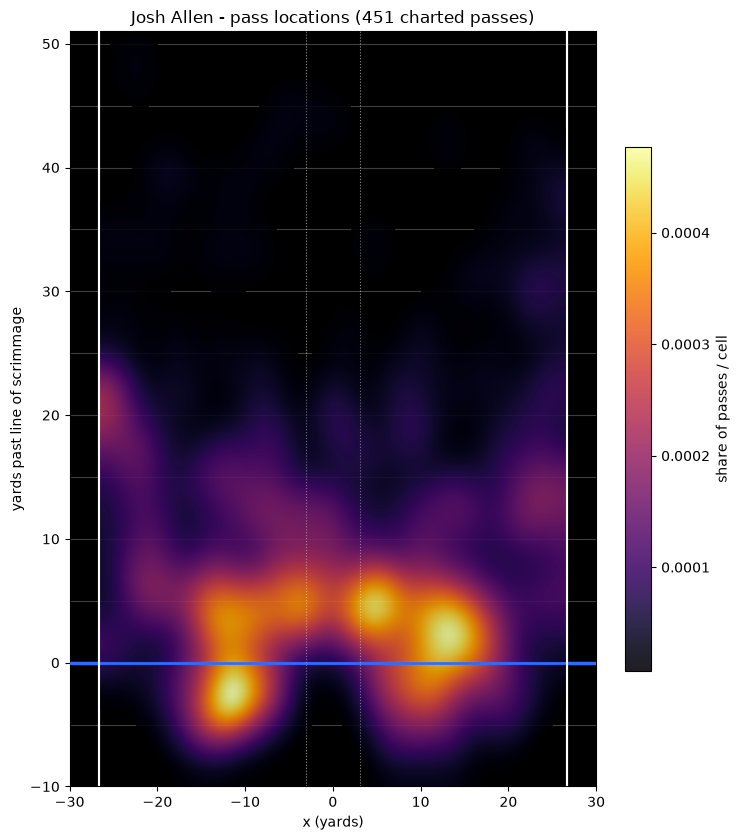

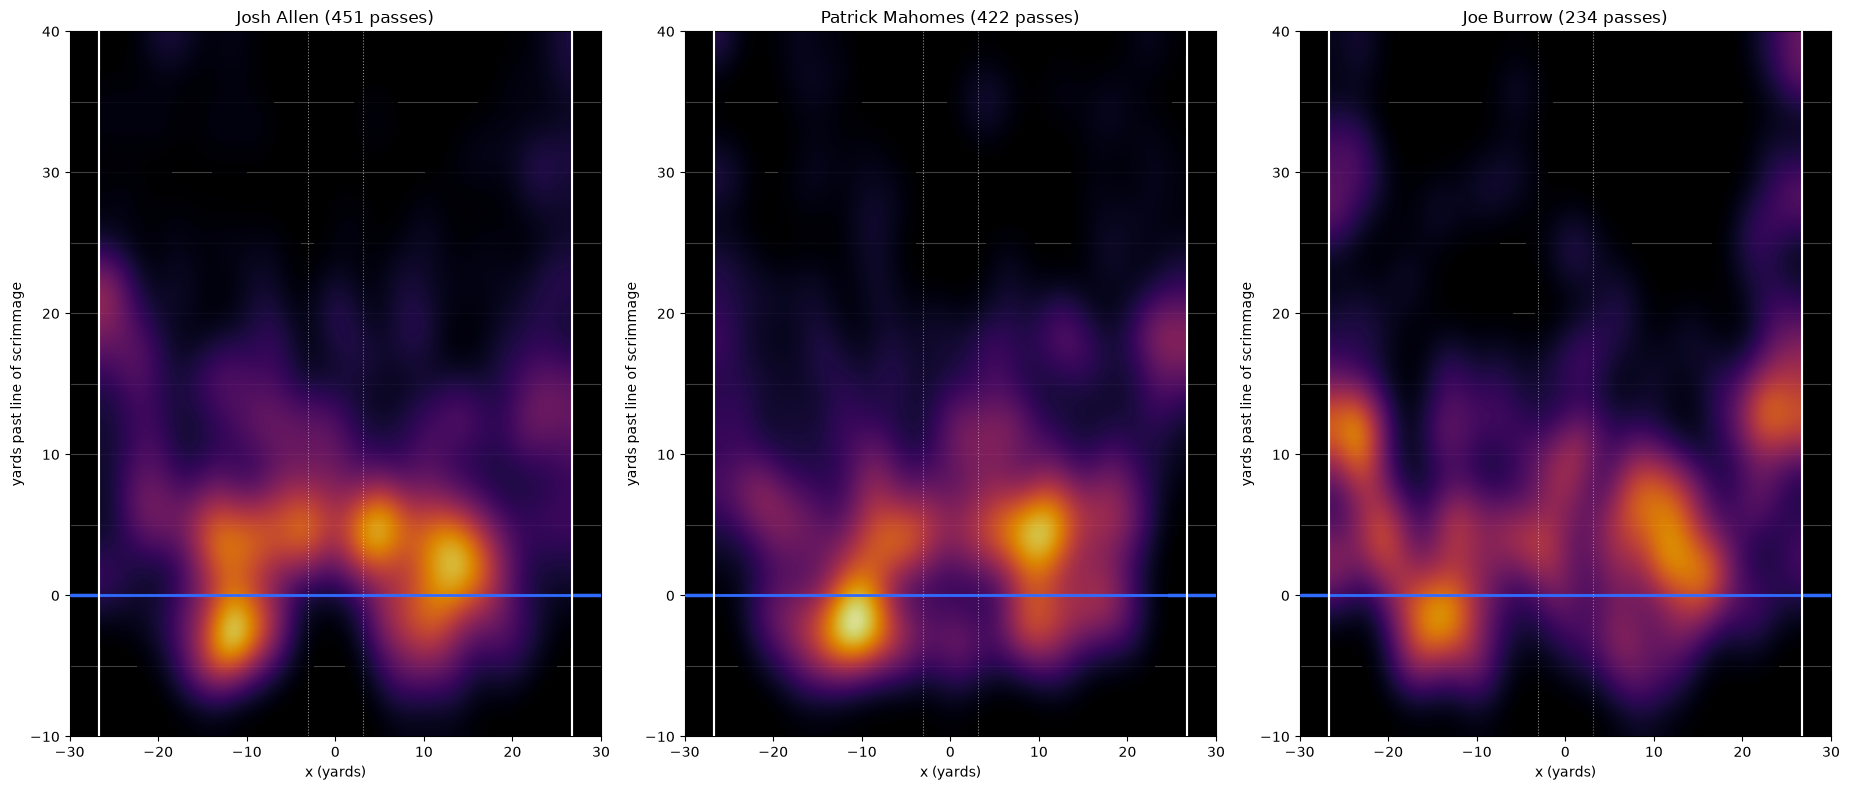

In [226]:
# --- QB PASS-LOCATION HEATMAP ---
# tip: passes['name'].unique() lists the QBs available
qb = 'Josh Allen'
weeks = list(range(1, 23))

d = passes[(passes['name'] == qb) & (passes['week'].isin(weeks)) & passes['located']]
fig, ax = plt.subplots(figsize=(7.5, 8.5))
im, _ = field_heatmap(ax, d['x_coord'], d['y_coord'], ymax=max(35, d['y_coord'].max() + 3))
ax.set_title(f'{qb} - pass locations ({len(d)} charted passes)')
fig.colorbar(im, ax=ax, fraction=0.045, label='share of passes / cell')
plt.tight_layout()
plt.show()

# --- compare several QBs side by side, one shared color scale ---
qbs = ['Josh Allen', 'Patrick Mahomes', 'Joe Burrow']
subsets = [passes[(passes['name'] == q) & (passes['week'].isin(weeks)) & passes['located']] for q in qbs]

# a first pass to find a shared vmax, so darker/brighter is comparable across panels
# (done before creating the real comparison figure below - plt.close('all') here would
# otherwise also close it)
peaks = []
for q, d in zip(qbs, subsets):
    if len(d):
        _, m = field_heatmap(plt.subplots()[1], d['x_coord'], d['y_coord'])
        peaks.append(m)
    plt.close('all')
shared_vmax = max(peaks) if peaks else None

fig, axes = plt.subplots(1, len(qbs), figsize=(6.2 * len(qbs), 8), squeeze=False)
axes = axes[0]
for ax, name, d in zip(axes, qbs, subsets):
    if d.empty:
        ax.set_title(f'{name}: no data')
        ax.axis('off')
        continue
    im, _ = field_heatmap(ax, d['x_coord'], d['y_coord'], ymax=40, vmax=shared_vmax)
    ax.set_title(f'{name} ({len(d)} passes)')
plt.tight_layout()
plt.show()

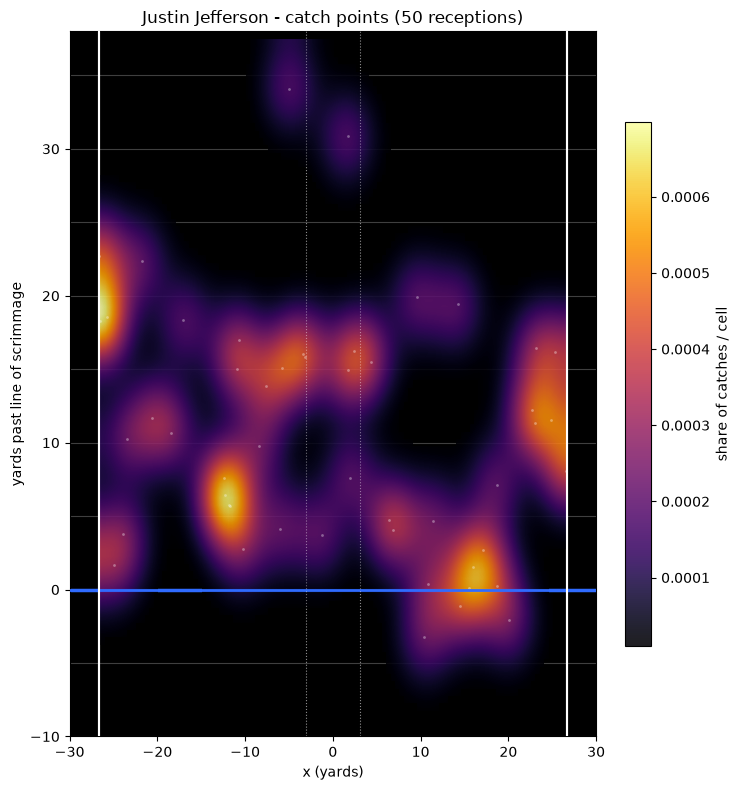

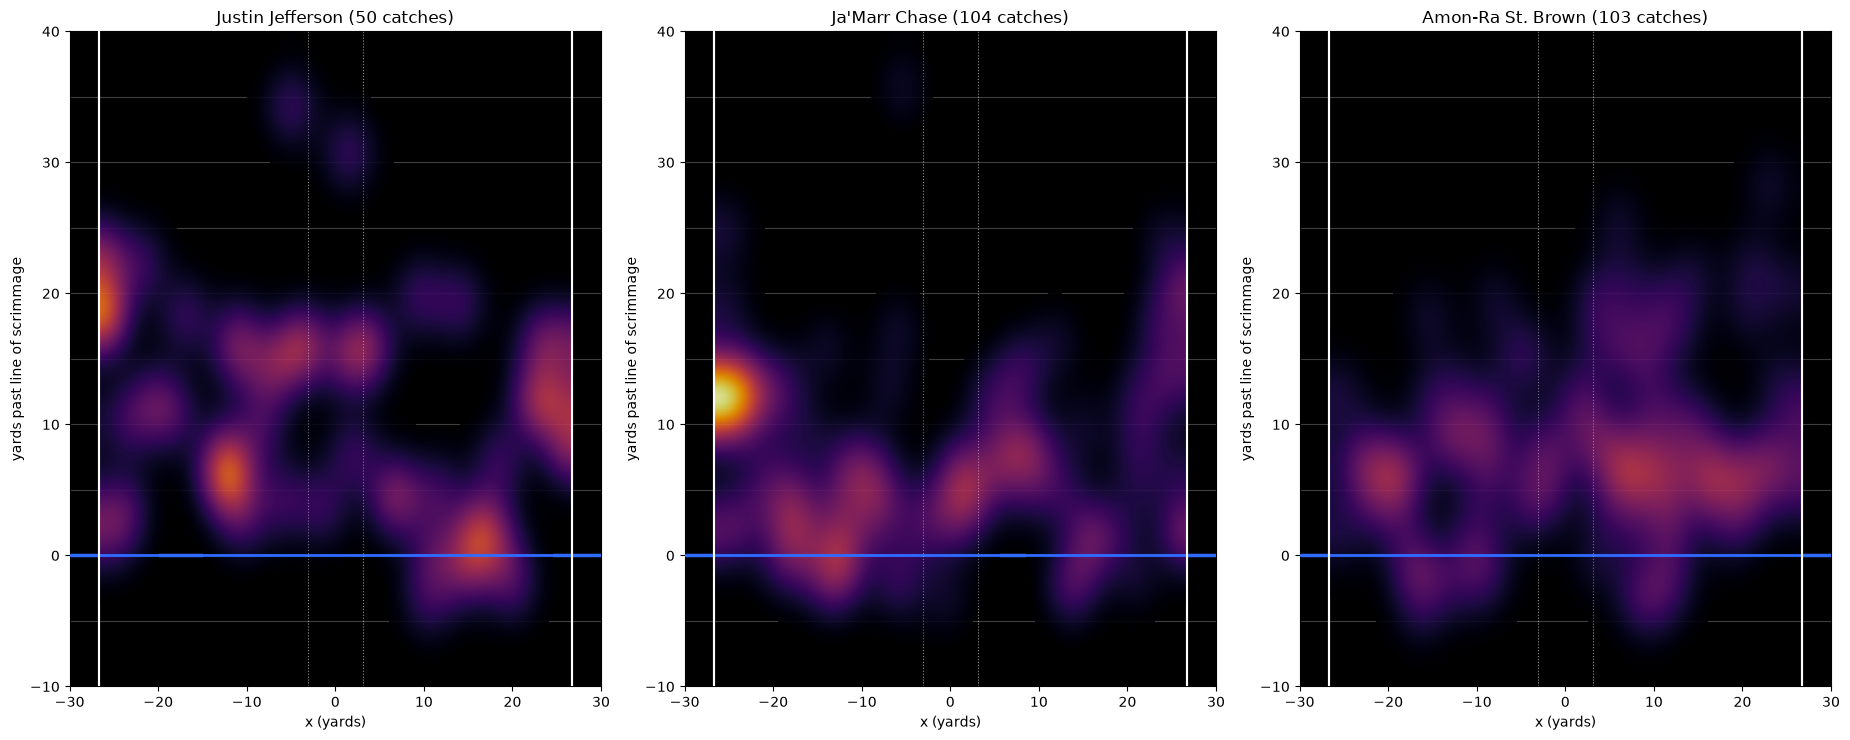

In [227]:
# --- RECEIVER CATCH-LOCATION HEATMAP (before YAC) ---
# tip: routes['name'].unique() lists the receivers available
receiver = 'Justin Jefferson'
weeks = list(range(1, 23))

d = routes[(routes['name'] == receiver) & (routes['week'].isin(weeks))]
cp = catch_points(d)
fig, ax = plt.subplots(figsize=(7.5, 8))
im, _ = field_heatmap(ax, cp['x_coord'], cp['y_coord'], ymax=max(30, cp['y_coord'].max() + 3), show_points=True)
ax.set_title(f'{receiver} - catch points ({len(cp)} receptions)')
fig.colorbar(im, ax=ax, fraction=0.045, label='share of catches / cell')
plt.tight_layout()
plt.show()

# --- compare several receivers side by side, one shared color scale ---
receivers = ['Justin Jefferson', 'Ja\'Marr Chase', 'Amon-Ra St. Brown']
cps = [catch_points(routes[(routes['name'] == r) & (routes['week'].isin(weeks))]) for r in receivers]

peaks = []
for cp in cps:
    if len(cp):
        _, m = field_heatmap(plt.subplots()[1], cp['x_coord'], cp['y_coord'])
        peaks.append(m)
    plt.close('all')
shared_vmax = max(peaks) if peaks else None

fig, axes = plt.subplots(1, len(receivers), figsize=(6.2 * len(receivers), 7.5), squeeze=False)
axes = axes[0]
for ax, name, cp in zip(axes, receivers, cps):
    if cp.empty:
        ax.set_title(f'{name}: no data')
        ax.axis('off')
        continue
    im, _ = field_heatmap(ax, cp['x_coord'], cp['y_coord'], ymax=40, vmax=shared_vmax)
    ax.set_title(f'{name} ({len(cp)} catches)')
plt.tight_layout()
plt.show()

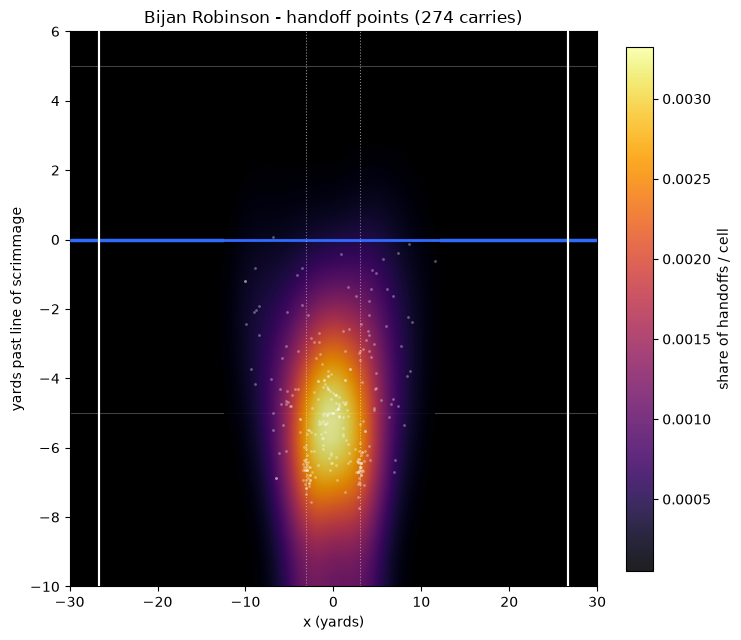

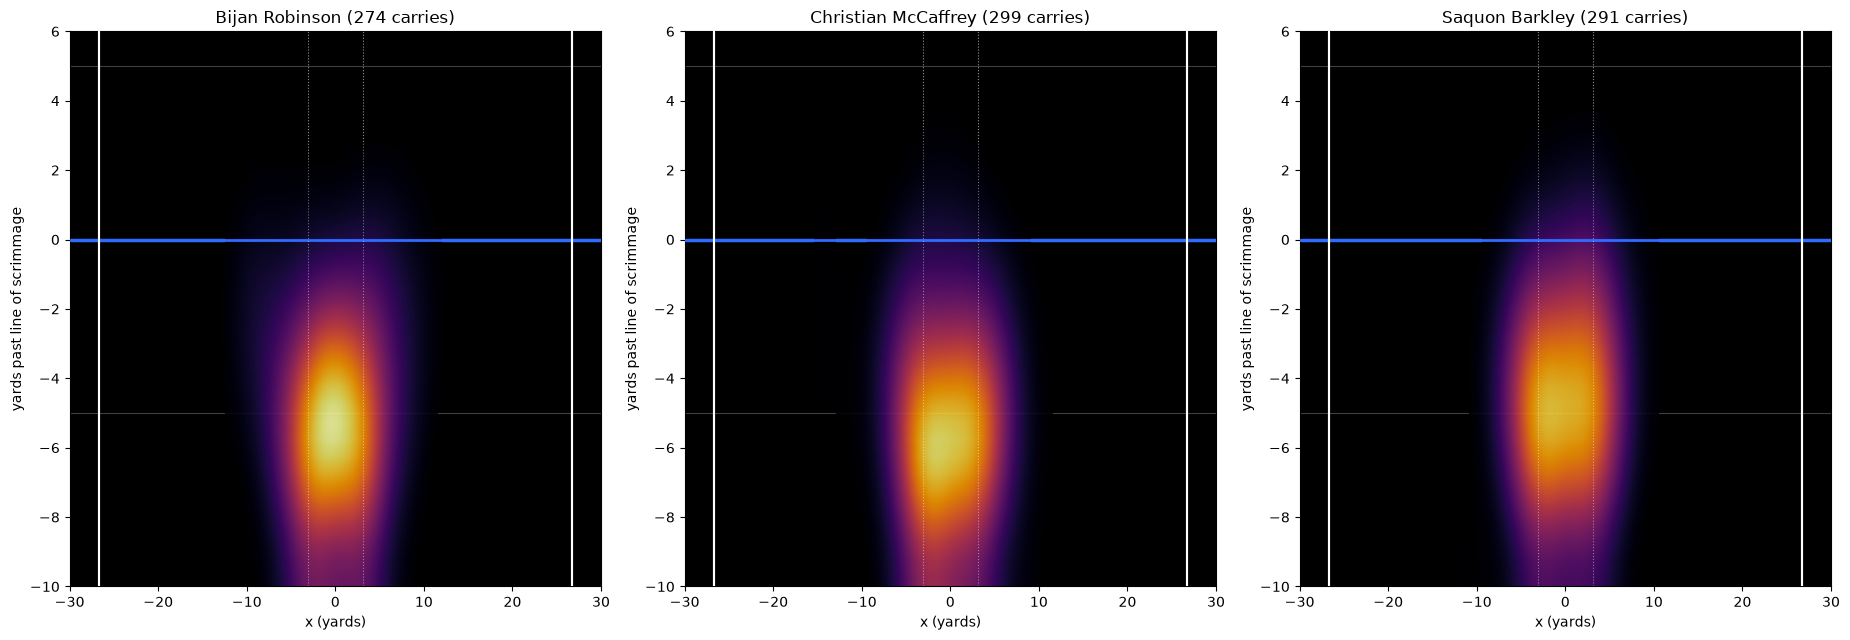

In [228]:
# --- RB HANDOFF-POINT HEATMAP ---
# tip: carries['name'].unique() lists the backs available
back = 'Bijan Robinson'
weeks = list(range(1, 23))

d = carries[(carries['name'] == back) & (carries['week'].isin(weeks))]
hp = handoff_points(d)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im, _ = field_heatmap(ax, hp['x_coord'], hp['y_coord'], ymin=-10, ymax=6, show_points=True)
ax.set_title(f'{back} - handoff points ({len(hp)} carries)')
fig.colorbar(im, ax=ax, fraction=0.045, label='share of handoffs / cell')
plt.tight_layout()
plt.show()

# --- compare several backs side by side, one shared color scale ---
backs = ['Bijan Robinson', 'Christian McCaffrey', 'Saquon Barkley']
hps = [handoff_points(carries[(carries['name'] == b) & (carries['week'].isin(weeks))]) for b in backs]

peaks = []
for hp in hps:
    if len(hp):
        _, m = field_heatmap(plt.subplots()[1], hp['x_coord'], hp['y_coord'], ymin=-10, ymax=6)
        peaks.append(m)
    plt.close('all')
shared_vmax = max(peaks) if peaks else None

fig, axes = plt.subplots(1, len(backs), figsize=(6.2 * len(backs), 6.5), squeeze=False)
axes = axes[0]
for ax, name, hp in zip(axes, backs, hps):
    if hp.empty:
        ax.set_title(f'{name}: no data')
        ax.axis('off')
        continue
    im, _ = field_heatmap(ax, hp['x_coord'], hp['y_coord'], ymin=-10, ymax=6, vmax=shared_vmax)
    ax.set_title(f'{name} ({len(hp)} carries)')
plt.tight_layout()
plt.show()